# Air quality on Vienna City Marathon dates

the data for this was sourced from https://researchdata.tuwien.ac.at/records/mtha8-w2406, https://eeadmz1-downloads-webapp.azurewebsites.net/

To correctly illustrate the air quality during the marathon, sensors close to the course were choosen. This means that the sensors at the following locations were selected: Stefansplatz, Taborstraße, A23-Wehlistraße, Hietzinger Kai. For the sake of simplicity, and because the original data is quite large, only the final cleaned file (vienna_marathon_component_trends.csv) was added to git.

## data acquisition

### getting pre 2021 data

Importing relevant libraries

In [3]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

Access data from the relevant_data folder

In [ ]:
data_dir = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\relevant_data\stations"

Define relevant marathon dates

In [89]:
marathon_dates = {
    2017: "2017-04-23",
    2018: "2018-04-22", 2019: "2019-04-07",
    2021: "2021-09-12", 2022: "2022-04-24", 2023: "2023-04-23",
    2024: "2024-04-21", 2025: "2025-04-06", 2026: "2026-04-19"
}

Create list for targets to search for

In [90]:
target_patterns = []
for year, date_str in marathon_dates.items():
    dt = pd.to_datetime(date_str)
    suffix = f"HMW_{dt.strftime('%y.%m.%d')}"
    target_patterns.append((year, suffix, dt.date()))

all_filtered_data = []

print("Scanning local station folders for specific marathon days...")

Scanning local station folders for specific marathon days...


Find all station directories inside  data directory

In [91]:
if os.path.exists(data_dir):
    stations = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    for station in stations:
        for year, suffix, actual_date in target_patterns:
            # Construct the direct path to the file
            # Example: data_dir/A23_PM10G/2016/HMW_16.04.10
            target_file_path = os.path.join(data_dir, station, str(year), suffix)

            if os.path.exists(target_file_path):
                try:
                    # Read the space-separated data file
                    df = pd.read_csv(
                        target_file_path,
                        sep=r'\s+',
                        header=None,
                        low_memory=False
                    )

                    # Rename key columns cleanly
                    df = df.rename(columns={0: 'Time', 1: 'Value'})

                    # Add metadata columns
                    df['Date'] = actual_date
                    df['Station'] = station

                    # Keep only essential columns
                    df = df[['Date', 'Time', 'Station', 'Value']]
                    all_filtered_data.append(df)
                    print(f"-> Found and processed: {station} ({year})")

                except Exception as e:
                    print(f"Error reading file {target_file_path}: {e}")
else:
    print(f"Error: The directory path '{data_dir}' does not exist. Please check your path syntax.")

Compile and save results to csv

In [92]:
if all_filtered_data:
    final_df = pd.concat(all_filtered_data, ignore_index=True)

    # Save it straight into your main project directory next to relevant_data
    output_path = os.path.join(os.path.dirname(data_dir), "vienna_marathon_air_quality_all_years.csv")
    final_df.to_csv(output_path, index=False)

    print(f"\n Success! Combined dataset saved to: {output_path}")
    print(f"Total rows gathered: {len(final_df)}")
else:
    print("\nNo matching files found. Check that your folder structure inside 'relevant_data' matches STATION/YEAR/HMW_date.")


No matching files found. Check that your folder structure inside 'relevant_data' matches STATION/YEAR/HMW_date.


Now the relevant data was saved in a single file. However to work with this data, the data of a single day (regardless of time, to not falsify the data a time window in which most people complete the marathon (9:00-16:00) was chosen)

In [93]:
csv_path = r"\Users\aylin\DataspellProjects\Bigdata_eng_prj\relevant_data\vienna_marathon_air_quality_all_years.csv"

df = pd.read_csv(csv_path)

In [94]:
df['Time'] = df['Time'].astype(str).str.zfill(4)
race_hours_df = df[(df['Time'] >= '0900') & (df['Time'] <= '1600')].copy()
race_hours_df['Year'] = pd.to_datetime(race_hours_df['Date']).dt.year

In [95]:
hourly_avg = race_hours_df.groupby(['Year', 'Station'])['Value'].mean().reset_index()

In [96]:
final_analysis_df = hourly_avg.pivot(index='Year', columns='Station', values='Value')
print(final_analysis_df.head())

Station     A23_CO     A23_NO    A23_NO2  A23_PM10G  A23_PM10S  A23_PM25G  \
Year                                                                        
2017      0.161021  10.866867  13.204247      6.825   5.120140      4.010   
2018    -53.129157   5.127340  17.245000     29.761  30.874533     18.074   
2019      0.180462   0.993837   6.751567     21.611  17.491333     16.157   
2021    -53.124846   4.287800  10.956660     14.635   9.596207        NaN   

Station  A23_PM25S   A23_SO2    MBA_CO     MBA_NO    MBA_NO2    STEF_NO  \
Year                                                                      
2017      2.429273  1.299720  0.143531   5.066647   7.044793 -52.609907   
2018     16.477733  0.867960  0.175585 -47.711247 -40.386607   0.000000   
2019     14.880200  0.635913  0.260323  16.600800  22.282333 -52.495725   
2021      6.795640  0.015629  0.183599 -48.984340 -44.854533   0.269445   

Station   STEF_NO2     STEF_O3   STEF_SO2  TAB_PM10G  TAB_PM10S  TAB_PM25G  \
Year    

In [97]:
final_analysis_df.to_csv("marathon_race_hours_pollution.csv")

To further simplify the data, all pollution measured (CO,NO,NO2,O3,PM10G,PM10S,PM25G,PM25S,SO2,TSP) regardless of location was combined into one value. Additionally, to avoid negative values (which occures with sensors sometimes when the air is exceptionally clean and of course doesn't mean that there is negative pollution) values were clipped so that the lowest possible value is 0.

In [98]:
clean_hours_csv = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\marathon_race_hours_pollution.csv"

In [99]:
if os.path.exists(clean_hours_csv):
    df = pd.read_csv(clean_hours_csv, index_col='Year')
    df = df.clip(lower=0.0)

    column_groups = {col: col.split('_')[-1] for col in df.columns}

    city_wide_trends = df.T.groupby(column_groups).mean().T

    dest_folder = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj"
    output_file = os.path.join("CSV", "vienna_marathon_component_trends.csv")

    city_wide_trends.to_csv(output_file)
    print(f" Success! The simplified trends are saved at:\n--> {output_file}")

    # Show a quick preview of the results
    print("\nFile Preview (City-Wide Averages per Component):")
    print(city_wide_trends.head())
else:
    print(f"Error: Could not locate '{clean_hours_csv}'. Double-check the filename in your project folder.")

 Success! The simplified trends are saved at:
--> CSV\vienna_marathon_component_trends.csv

File Preview (City-Wide Averages per Component):
            CO        NO       NO2         O3    PM10G      PM10S    PM25G  \
Year                                                                         
2017  0.152276  5.311171  6.749680   0.000000   6.5200   4.206237   3.8600   
2018  0.087793  1.709113  7.768656   0.000000  30.5420  28.996167  19.1440   
2019  0.220392  5.864879  9.677967  46.645400  21.9160  17.190867  15.8755   
2021  0.091799  1.519082  4.637013  42.207667  13.9355   8.455553  10.3870   

          PM25S       SO2  
Year                       
2017   2.477440  1.112097  
2018  16.356033  0.777053  
2019  14.293183  0.614187  
2021   6.220317  0.007815  


Replace suspicious 0s with NAs and turn PMM10G/PM10s and PM25G/PM25S into just PM10 and PM25

In [100]:
df = pd.read_csv(r"CSV\vienna_marathon_component_trends.csv")

df["O3"] = df["O3"].replace(0.0, np.nan)

df["pm10"] = df[["PM10G", "PM10S"]].mean(axis=1)
df["pm25"] = df[["PM25G", "PM25S"]].mean(axis=1)

df = df.drop(columns=["PM10G", "PM10S", "PM25G", "PM25S", "TSP"], errors="ignore")
print(df)
df.to_csv("CSV/vienna_marathon_component_trends.csv", index=False)

   Year        CO        NO       NO2         O3       SO2       pm10  \
0  2017  0.152276  5.311171  6.749680        NaN  1.112097   5.363118   
1  2018  0.087793  1.709113  7.768656        NaN  0.777053  29.769083   
2  2019  0.220392  5.864879  9.677967  46.645400  0.614187  19.553433   
3  2021  0.091799  1.519082  4.637013  42.207667  0.007815  11.195527   

        pm25  
0   3.168720  
1  17.750017  
2  15.084342  
3   8.303658  


### Adding data after 2021

#### data 2021-2024

In [ ]:
!pip install pyarrow

Get an overview of the data structure

In [101]:
import os
import pandas as pd
import pyarrow.parquet as pq

parquet_folder = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\relevant_data\parquets"

if os.path.exists(parquet_folder):
    files = [f for f in os.listdir(parquet_folder) if f.endswith(".parquet")]
    if files:
        sample_file = os.path.join(parquet_folder, files[0])
        print(f"Checking structure of sample file: {files[0]}\n")

        # FIX: Open using native pyarrow engine directly to bypass the pandas bug
        table = pq.read_table(sample_file)
        df_sample = table.to_pandas()

        print("--- Available Columns ---")
        print(df_sample.columns.tolist())

        print("\n--- First 5 Rows of Data ---")
        print(df_sample.head())
    else:
        print(f"The folder is empty! No .parquet files found in: {parquet_folder}")
else:
    print(f"Folder path does not exist: {parquet_folder}")

Checking structure of sample file: SPO.09.A23.65509.1.1.parquet

--- Available Columns ---
['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog']

--- First 5 Rows of Data ---
             Samplingpoint  Pollutant               Start                 End  \
0  AT/SPO.09.A23.65509.1.1          1 2021-01-01 00:00:00 2021-01-01 01:00:00   
1  AT/SPO.09.A23.65509.1.1          1 2021-01-01 01:00:00 2021-01-01 02:00:00   
2  AT/SPO.09.A23.65509.1.1          1 2021-01-01 02:00:00 2021-01-01 03:00:00   
3  AT/SPO.09.A23.65509.1.1          1 2021-01-01 03:00:00 2021-01-01 04:00:00   
4  AT/SPO.09.A23.65509.1.1          1 2021-01-01 04:00:00 2021-01-01 05:00:00   

                  Value    Unit AggType  Validity  Verification ResultTime  \
0  0.013323000000000000  ug.m-3    hour         1             1 2022-01-01   
1  0.172102000000000000  ug.m-3    hour         1             1 2022-01-01   
2  0.3

In [102]:
root_dir = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj"
parquet_folder = os.path.join(root_dir, "relevant_data", "parquets")
output_csv = os.path.join(root_dir, "relevant_data", "marathon_patch_2021_2024.csv")
pollutant_map = {1: 'SO2', 5: 'CO', 8: 'NO2', 7: 'NO', 38: 'NOX', 6001: 'PM25G', 5014: 'PM10G'}
target_dates = [pd.to_datetime(d).date() for d in ["2021-09-12", "2022-04-24", "2023-04-23", "2024-04-21"]]
extracted_records = []
print(f"Scanning target folder: {parquet_folder} for marathon days...")

Scanning target folder: C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\relevant_data\parquets for marathon days...


In [103]:
if os.path.exists(parquet_folder):
    for file in os.listdir(parquet_folder):
        if file.endswith(".parquet"):
            try:
                df_parquet = pq.read_table(os.path.join(parquet_folder, file)).to_pandas()
                if 'Start' in df_parquet.columns and 'Value' in df_parquet.columns:
                    df_parquet['Parsed_DateTime'] = pd.to_datetime(df_parquet['Start'])
                    df_parquet['Parsed_Date'] = df_parquet['Parsed_DateTime'].dt.date

                    matched_rows = df_parquet[df_parquet['Parsed_Date'].isin(target_dates)].copy()
                    if not matched_rows.empty:
                        matched_rows['Time'] = matched_rows['Parsed_DateTime'].dt.strftime('%H%M')
                        station_code = file.split('.')[2] if len(file.split('.')) > 2 else "Unknown"

                        for _, row in matched_rows.iterrows():
                            p_code = int(row.get('Pollutant', 0))
                            p_name = pollutant_map.get(p_code, f"P{p_code}")

                            extracted_records.append({
                                'Date': str(row['Parsed_Date']),
                                'Time': row['Time'],
                                'Station': f"{station_code}_{p_name}", # Matches old format!
                                'Value': row['Value']
                            })
            except Exception:
                continue

    if extracted_records:
        pd.DataFrame(extracted_records).to_csv(output_csv, index=False)
        print(f" Re-extracted 2021-2024 data cleanly: {len(extracted_records)} rows.")

 Re-extracted 2021-2024 data cleanly: 1421 rows.


#### data 2025-2026

making sure the data provided is up to date

In [104]:
if os.path.exists(new_parquet_folder):
    files = [f for f in os.listdir(new_parquet_folder) if f.endswith(".parquet")]
    if files:
        sample_file = os.path.join(new_parquet_folder, files[0])

        # Read the file via PyArrow
        table = pq.read_table(sample_file)
        df_sample = table.to_pandas()

        if 'Start' in df_sample.columns:
            df_sample['Start'] = pd.to_datetime(df_sample['Start'])
            min_date = df_sample['Start'].min()
            max_date = df_sample['Start'].max()

            print(f"File Inspected: {files[0]}")
            print(f"-> Earliest date in this file: {min_date.strftime('%Y-%m-%d')}")
            print(f"-> Latest date in this file:   {max_date.strftime('%Y-%m-%d')}")
        else:
            print("Could not find a 'Start' timestamp column in this file.")
    else:
        print(f"The folder is empty! Place your new files in: {new_parquet_folder}")
else:
    print(f"Folder path does not exist: {new_parquet_folder}")

File Inspected: SPO.09.A23.65511.8.1.parquet
-> Earliest date in this file: 2025-01-01
-> Latest date in this file:   2026-05-31


In [105]:
root_dir = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj"
new_parquet_folder = os.path.join(root_dir, "relevant_data", "parquets_2025_2026")
output_csv = os.path.join(root_dir, "relevant_data", "marathon_patch_2025_2026.csv")

Adding relevant dates

In [106]:
pollutant_map = {1: 'SO2', 5: 'CO', 8: 'NO2', 7: 'NO', 38: 'NOX', 6001: 'PM25G', 5014: 'PM10G'}
extracted_records = []

In [107]:
if os.path.exists(new_parquet_folder):
    for file in os.listdir(new_parquet_folder):
        if file.endswith(".parquet"):
            try:
                df_parquet = pq.read_table(os.path.join(new_parquet_folder, file)).to_pandas()
                if 'Start' in df_parquet.columns and 'Value' in df_parquet.columns:
                    df_parquet['Parsed_DateTime'] = pd.to_datetime(df_parquet['Start'], utc=True).dt.tz_convert('Europe/Vienna')
                    df_parquet['Year'] = df_parquet['Parsed_DateTime'].dt.year
                    df_parquet['Month'] = df_parquet['Parsed_DateTime'].dt.month
                    df_parquet['Day'] = df_parquet['Parsed_DateTime'].dt.day

                    matched_rows = df_parquet[
                        ((df_parquet['Year'] == 2025) & (df_parquet['Month'] == 4) & (df_parquet['Day'] == 6)) |
                        ((df_parquet['Year'] == 2026) & (df_parquet['Month'] == 4) & (df_parquet['Day'] == 19))
                    ].copy()

                    if not matched_rows.empty:
                        matched_rows['Time'] = matched_rows['Parsed_DateTime'].dt.strftime('%H%M')
                        matched_rows['Date_Str'] = matched_rows['Parsed_DateTime'].dt.strftime('%Y-%m-%d')
                        station_code = file.split('.')[2] if len(file.split('.')) > 2 else "Unknown"

                        for _, row in matched_rows.iterrows():
                            p_code = int(row.get('Pollutant', 0))
                            p_name = pollutant_map.get(p_code, f"P{p_code}")

                            extracted_records.append({
                                'Date': row['Date_Str'],
                                'Time': row['Time'],
                                'Station': f"{station_code}_{p_name}", # Matches old format!
                                'Value': row['Value']
                            })
            except Exception:
                continue

    if extracted_records:
        pd.DataFrame(extracted_records).to_csv(output_csv, index=False)
        print(f" Re-extracted 2025-2026 data cleanly: {len(extracted_records)} rows.")

 Re-extracted 2025-2026 data cleanly: 672 rows.


## combining the different data sources


defining all paths

In [108]:
root_dir = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj"
data_dir = os.path.join(root_dir, "relevant_data")

master_csv = os.path.join(root_dir, "vienna_marathon_air_quality_all_years.csv")
patch_21_24 = os.path.join(data_dir, "marathon_patch_2021_2024.csv")
patch_25_26 = os.path.join(data_dir, "marathon_patch_2025_2026.csv")

race_hours_output = os.path.join(root_dir, "marathon_race_hours_pollution.csv")
component_trends_output = os.path.join(root_dir, "CSV", "vienna_marathon_component_trends.csv")

Load and concatenate all raw datasets

In [109]:
print("Loading and consolidating raw datasets...")
dfs_to_combine = []

if os.path.exists(master_csv): dfs_to_combine.append(pd.read_csv(master_csv))
if os.path.exists(patch_21_24): dfs_to_combine.append(pd.read_csv(patch_21_24))
if os.path.exists(patch_25_26): dfs_to_combine.append(pd.read_csv(patch_25_26))

combined_raw_df = pd.concat(dfs_to_combine, ignore_index=True)

Loading and consolidating raw datasets...


combine data

In [110]:
combined_raw_df = combined_raw_df[combined_raw_df['Station'].astype(str).str.contains('_')].copy()

drop duplicates

In [111]:
combined_raw_df = combined_raw_df.drop_duplicates(subset=['Date', 'Time', 'Station'])

save raw data

In [112]:
combined_raw_df.to_csv(master_csv, index=False)

Process race hours

In [113]:
combined_raw_df['Time'] = combined_raw_df['Time'].astype(str).str.zfill(4)
race_hours_df = combined_raw_df[(combined_raw_df['Time'] >= '0900') & (combined_raw_df['Time'] <= '1600')].copy()
race_hours_df['Year'] = pd.to_datetime(race_hours_df['Date']).dt.year

hourly_avg = race_hours_df.groupby(['Year', 'Station'])['Value'].mean().reset_index()
final_analysis_df = hourly_avg.pivot(index='Year', columns='Station', values='Value').clip(lower=0.0)
final_analysis_df.to_csv(race_hours_output)

get city wide component trends

In [114]:
component_mapping = final_analysis_df.columns.map(lambda x: x.split('_')[-1] if '_' in str(x) else str(x))
city_wide_trends = final_analysis_df.T.groupby(component_mapping).mean().T

clean up (in case station names slipped through)

In [115]:
rename_map = {'P1': 'SO2', 'P5': 'CO', 'P8': 'NO2', 'P7': 'NO', 'P38': 'NOX', 'P6001': 'PM25G', 'P5014': 'PM10G'}
city_wide_trends = city_wide_trends.rename(columns=rename_map)

In [116]:
valid_pollutants = ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10G', 'PM10S', 'PM25G', 'PM25S', 'SO2', 'TSP']
city_wide_trends = city_wide_trends[[c for c in city_wide_trends.columns if c in valid_pollutants]]

city_wide_trends.to_csv(component_trends_output)

In [117]:
print(city_wide_trends.tail(6))

Station         CO          NO        NO2       NOX         O3    PM10G  \
Year                                                                      
2021      2.363414    1.519082   6.268728  0.264975  42.207667  13.9355   
2022     11.038678   74.999375  13.770677  0.000000        NaN      NaN   
2023     17.464874  104.835625  11.451510  0.387956        NaN      NaN   
2024      9.669990   86.689375   8.132235  0.010826        NaN      NaN   
2025      7.378703   88.695000   7.328395  0.383234        NaN      NaN   
2026     21.900125   89.024875  23.998326  1.847486        NaN      NaN   

Station     PM10S      PM25G     PM25S       SO2  TSP  
Year                                                   
2021     8.455553   8.245162  6.220317  0.007815  NaN  
2022          NaN   6.029162       NaN  0.559385  NaN  
2023          NaN  10.931837       NaN  1.186979  NaN  
2024          NaN   7.542422       NaN  2.174765  NaN  
2025          NaN   3.518700       NaN  1.383681  NaN  
2026   

## Visualisation

load data sets

In [119]:
aq = pd.read_csv("CSV/vienna_marathon_component_trends.csv")
weather = pd.read_csv("CSV/weather.csv")
aq = aq.rename(columns={"Year": "year"})
df = weather.merge(aq, on="year", how="left")

The following plot shows the polutants in the air during marathon day. For some years certain polutants are missing-the values were deliberatedly left as NAs to not falsify anything but also to not lose data, since the time span is rather narrow.

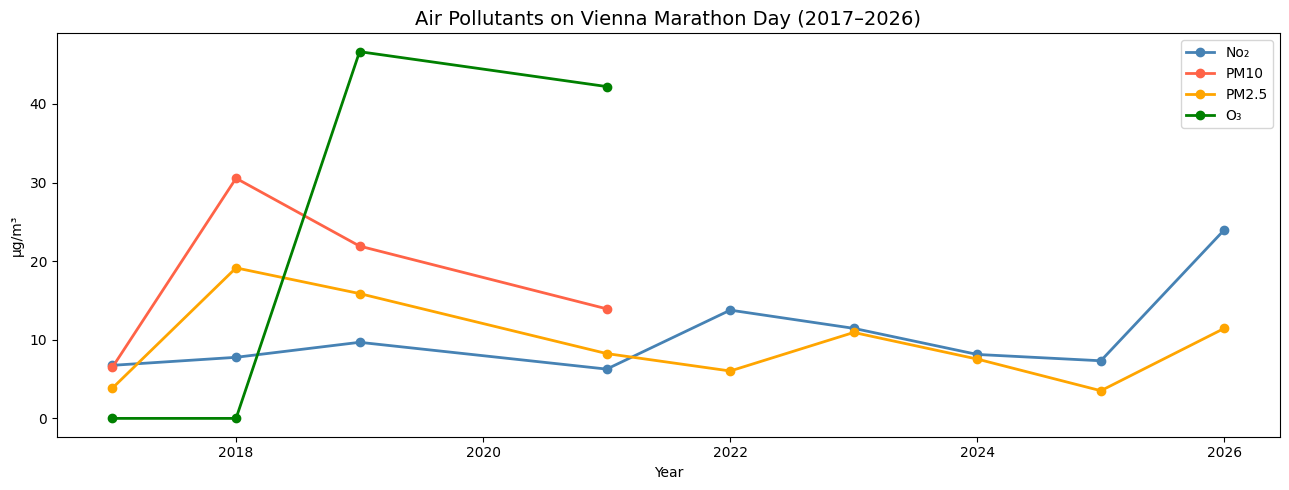

In [120]:
fig, ax = plt.subplots(figsize=(13, 5))
for col, color, label in [
    ("NO2",   "steelblue", "No₂"),
    ("PM10G", "tomato",    "PM10"),
    ("PM25G", "orange",    "PM2.5"),
    ("O3",    "green",     "O₃"),
]:
    ax.plot(df["year"], df[col], marker="o", linewidth=2, label=label, color=color)
ax.set_title("Air Pollutants on Vienna Marathon Day (2017–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.savefig("aq_pollutant_trends.png", dpi=150)
plt.show()

The following plot shows the correlation between weather and air quality data points such as humidity or PM10 pollutants in the air.

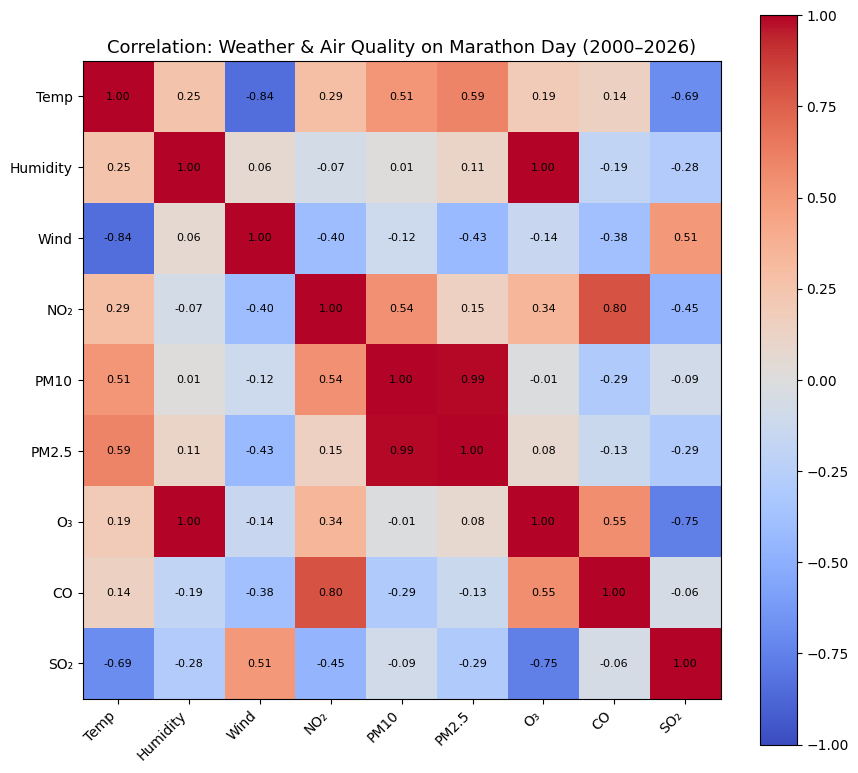

In [121]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

corr_cols = ["temp_c", "humidity", "wind_kph", "NO2", "PM10G", "PM25G", "O3", "CO", "SO2"]

corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))

labels = ["Temp", "Humidity", "Wind", "NO₂", "PM10", "PM2.5", "O₃", "CO", "SO₂"]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)


for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.iloc[i, j]

        text_val = f"{val:.2f}" if not pd.isna(val) else "NaN"
        ax.text(j, i, text_val, ha="center", va="center", fontsize=8)

plt.colorbar(im)
ax.set_title("Correlation: Weather & Air Quality on Marathon Day (2000–2026)", fontsize=13)
plt.tight_layout()


plt.savefig("aq_correlation.png", dpi=150)
plt.show()